In [39]:
import torch
import os
import glob
from utilities import *
import matplotlib.pyplot as plt

device = torch.device('cpu')

In [109]:
seeds = [0, 1, 42] 
noise_levels = [0, 0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1] 
n_train = 1000
n_test = 1000
steps = 200
grids = [3, 5, 10, 20, 50, 100]
pct = [0, 0.5, 1, 2, 5]
lr = 1.0
k = 3

In [45]:
def train_on_gaussian(seed, noise, dim, data):
    dataset_path = os.path.join("datasets", f"seed {seed}", f"{data}_dataset_dim{dim}_seed{seed}.pt")
    if not os.path.exists(dataset_path):
        dataset = generate_dataset(dim=dim, seed=seed, data=data, n_train=n_train, n_test=n_test)
    else:
        dataset = torch.load(dataset_path, map_location=torch.device('cpu'))
    dataset = torch.load(os.path.join('datasets', f'seed {seed}', f'{data}_dataset_dim{dim}_seed{seed}.pt'), map_location='cpu')
    if data == 'A':
        std = 0.3885
    elif data == 'C':
        std = 0.5774
    sigma = float(noise * std)
    print(seed, sigma)
    torch.manual_seed(seed)
    dataset['train_input'] = dataset['train_input'] + sigma * torch.randn_like(dataset['train_input'])
    dataset['test_input'] = dataset['test_input'] + sigma * torch.randn_like(dataset['test_input'])
    dataset['train_label'] = dataset['train_label'] + sigma * torch.randn_like(dataset['train_label'])
    dataset['test_label'] = dataset['test_label'] + sigma * torch.randn_like(dataset['test_label'])
    dir = os.path.join("datasets-noise", f"seed {seed}")
    os.makedirs(dir, exist_ok=True)
    torch.save(dataset, os.path.join(dir, f"{data}_dataset_dim{dim}_seed{seed}_{noise}.pt"))
    width = [dim, 1, 1]

    result = {}
    print(f'\nSeed {seed} | noise={noise}: running static KAN')
    result['static'] = train_kan(width=width, dataset=dataset, steps=steps, grids=grids, lr=lr, seed=seed, static=True, k=k, device=device)
    print(f'\nSeed {seed} | noise={noise}: running dynamic KAN')
    result['dynamic'] = train_kan(width=width, dataset=dataset, steps=steps, grids=grids, lr=lr, seed=seed, static=False, k=k, device=device)
    print(f'\nSeed {seed} | noise={noise}: running MLP')
    mlp_hidden_width = math.ceil((10*dim+11)/(dim+2)) - 1
    result['mlp'] = train_mlp(width=[dim, mlp_hidden_width, 1], dataset=dataset, steps=steps, lr=lr, seed=seed)

    
    dir = os.path.join('6-results-noise-gaussian', f'seed-{seed}')
    os.makedirs(dir, exist_ok=True)
    torch.save(result, os.path.join(dir, f'{data}_dim{dim}_noise_{sigma:.3f}.pt'))
    return result


In [ ]:
def train_kan_on_outliers(seed, outlier_pct, dim, data):
    dataset = torch.load(os.path.join('datasets', f'seed {seed}', f'{data}_dataset_dim{dim}_seed{seed}.pt'), map_location='cpu')
    
    dataset = {k: v.clone() for k, v in dataset.items()}
    
    outlier_pct_float = float(outlier_pct)
    if data == 'A':
        max_val = math.exp(math.sqrt(dim)/2.0)
    elif data == 'C':
        max_val = math.sqrt(dim)
    outlier_val = 1 * max_val 
    
    torch.manual_seed(seed)
    np.random.seed(seed)
    n_train_outliers = int(np.ceil(dataset['train_label'].shape[0] * outlier_pct_float / 100.0))
    if n_train_outliers > 0:
        train_indices = np.random.choice(dataset['train_label'].shape[0], n_train_outliers, replace=False)
        dataset['train_label'][train_indices] = outlier_val
    
    n_test_outliers = int(np.ceil(dataset['test_label'].shape[0] * outlier_pct_float / 100.0))
    if n_test_outliers > 0:
        test_indices = np.random.choice(dataset['test_label'].shape[0], n_test_outliers, replace=False)
        dataset['test_label'][test_indices] = outlier_val
    
    dir = os.path.join("datasets-noise-extreme", f"seed {seed}")
    os.makedirs(dir, exist_ok=True)
    torch.save(dataset, os.path.join(dir, f"{data}_dataset_dim{dim}_seed{seed}_{outlier_pct}.pt"))
    width = [dim, 1, 1]
    
    result = {}
    print(f'\nSeed {seed} | outlier%={outlier_pct_float}: running static KAN')
    result['static'] = train_kan(width=width, dataset=dataset, steps=steps, grids=grids, lr=lr, seed=seed, static=True, k=k, device=device)
    
    print(f'Seed {seed} | outlier%={outlier_pct_float}: running dynamic KAN')
    result['dynamic'] = train_kan(width=width, dataset=dataset, steps=steps, grids=grids, lr=lr, seed=seed, static=False, k=k, device=device)
    
    print(f'Seed {seed} | outlier%={outlier_pct_float}: running MLP')
    mlp_hidden_width = math.ceil((10*dim+11)/(dim+2)) - 1
    result['mlp'] = train_mlp(width=[dim, mlp_hidden_width, 1], dataset=dataset, steps=steps, lr=lr, seed=seed)
    
    dir = os.path.join('6-results-noise-outlier-new', f'seed-{seed}')
    os.makedirs(dir, exist_ok=True)
    torch.save(result, os.path.join(dir, f'{data}_dim{dim}_outlier_{outlier_pct_float:.1f}pct.pt'))
    return result


In [ ]:
for seed in seeds:
    for noise in noise_levels:
        train_on_gaussian(seed, noise, 100, 'C')
        train_on_gaussian(seed, noise, 5, 'C')
        train_on_gaussian(seed, noise, 5, 'A')

In [82]:
pct = [10, 20]

In [ ]:
for seed in seeds:
    for outlier_pct in pct:
        train_kan_on_outliers(seed, outlier_pct, 5, 'A')
        train_kan_on_outliers(seed, outlier_pct, 5, 'C')
        train_kan_on_outliers(seed, outlier_pct, 100, 'C')


In [66]:
def load_kan_results(data_name,  dim):

    compiled_results = {}
    
    search_pattern = os.path.join('6-results-noise-gaussian', 'seed-*', f'{data_name}_dim{dim}_noise_*.pt')
    matching_files = glob.glob(search_pattern)
    
    if not matching_files:
        print('No files found for equation')
        return compiled_results

    for file_path in matching_files:
        path_parts = file_path.split(os.sep)
        seed_str = [part for part in path_parts if part.startswith('seed-')][0]
        seed = int(seed_str.split('-')[1])
        filename = os.path.basename(file_path)
        sigma_str = filename.split('_noise_')[1].replace('.pt', '')
        sigma = float(sigma_str)
        result_data = torch.load(file_path, map_location='cpu', weights_only=False)
        
        if seed not in compiled_results:
            compiled_results[seed] = {}
            
        compiled_results[seed][sigma] = result_data

    print(f"Successfully loaded {len(matching_files)} result file(s).")
    return compiled_results

In [67]:
C_dim100 = load_kan_results('C', 100)
C_dim5 = load_kan_results('C', 5)
A_dim5 = load_kan_results('A', 5)

Successfully loaded 24 result file(s).
Successfully loaded 24 result file(s).
Successfully loaded 24 result file(s).


In [68]:
def plot_gaussian(experiments, seeds, x):
    from matplotlib.ticker import MaxNLocator

    x_plot = [i * 100 for i in x]

    plt.rcParams.update({
        'font.size': 13,
        'axes.titlesize': 20,
        'axes.labelsize': 20,
        'xtick.labelsize': 13,
        'ytick.labelsize': 15,
        'legend.fontsize': 20,
        'figure.titlesize': 30
    })

    fig, axes = plt.subplots(1, len(experiments), figsize=(6 * len(experiments), 6))
    if len(experiments) == 1:
        axes = [axes]

    for ax_idx, (ax, (results, data, dim)) in enumerate(zip(axes, experiments)):
        noise_values = sorted(results[seeds[0]].keys())
        print(noise_values)

        static_r2 = np.array([[results[s][n]['static']['r2s'][-1] for n in noise_values] for s in seeds])
        dynamic_r2 = np.array([[results[s][n]['dynamic']['r2s'][-1] for n in noise_values] for s in seeds])
        mlp_r2 = np.array([[results[s][n]['mlp']['r2s'][-1] for n in noise_values] for s in seeds])

        if ax_idx == 2:
            all_r2 = np.concatenate([static_r2.flatten(), dynamic_r2.flatten(), mlp_r2.flatten()])
            ymin_data = float(np.nanmin(all_r2))
            raw_ticks = np.array(sorted(MaxNLocator(nbins=5).tick_values(ymin_data, 1.0)))
            tick_step = float(raw_ticks[1] - raw_ticks[0]) if len(raw_ticks) >= 2 else 0.2

            if tick_step > 1.0:
                def transform(y, _s=tick_step):
                    arr = np.asarray(y, dtype=float)
                    return np.where(arr > 0, arr * _s, arr)
                below = raw_ticks[raw_ticks <= 0.0]
                ytick_pos = list(below) + [tick_step]
                ytick_labels = [str(int(v)) if v == int(v) else f"{v:.2f}" for v in below] + ["1"]
                ymin_t = ymin_data if ymin_data <= 0 else ymin_data * tick_step
                span = tick_step - ymin_t
                ylim = (ymin_t - span * 0.05, tick_step + span * 0.05)
            else:
                transform = lambda y: np.asarray(y, dtype=float)
                ytick_pos = sorted(set(float(t) for t in raw_ticks) | {1.0})
                ytick_labels = None
                span = 1.0 - ymin_data
                ylim = (ymin_data - span * 0.05, 1.0 + tick_step * 0.3)
        else:
            transform = lambda y: np.asarray(y, dtype=float)
            ytick_pos = None
            ytick_labels = None
            ylim = None
        ax.plot(x_plot, transform(static_r2.mean(axis=0)), marker='s', label='Static KAN')
        ax.fill_between(x_plot, transform(static_r2.min(axis=0)), transform(static_r2.max(axis=0)), alpha=0.2)

        ax.plot(x_plot, transform(dynamic_r2.mean(axis=0)), marker='^', label='Dynamic KAN')
        ax.fill_between(x_plot, transform(dynamic_r2.min(axis=0)), transform(dynamic_r2.max(axis=0)), alpha=0.2)

        ax.plot(x_plot, transform(mlp_r2.mean(axis=0)), marker='o', label='MLP')
        ax.fill_between(x_plot, transform(mlp_r2.min(axis=0)), transform(mlp_r2.max(axis=0)), alpha=0.2)

        ax.set_xlabel('Gaussian noise $\\sigma$ (symlog)')
        if ax_idx == 0:
            ax.set_ylabel('$R^2$')
        ax.set_title(f'$f_{data}$, d={dim}')

        ax.set_xscale('symlog')
        ax.set_xticks(x_plot)
        ax.set_xticklabels([f"{val:g}" for val in x])

        if ytick_pos is not None:
            ax.set_yticks(ytick_pos)
        if ytick_labels is not None:
            ax.set_yticklabels(ytick_labels)
        else:
            ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.2f}"))
        if ylim is not None:
            ax.set_ylim(ylim)

    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.05))
    fig.suptitle('Gaussian noise sensitivity across datasets', y=0.93)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
    fig.savefig('2-gaussian_noise.png', bbox_inches='tight', dpi=300)

[0.0, 0.004, 0.008, 0.019, 0.039, 0.078, 0.194, 0.389]
[0.0, 0.006, 0.012, 0.029, 0.058, 0.115, 0.289, 0.577]
[0.0, 0.006, 0.012, 0.029, 0.058, 0.115, 0.289, 0.577]


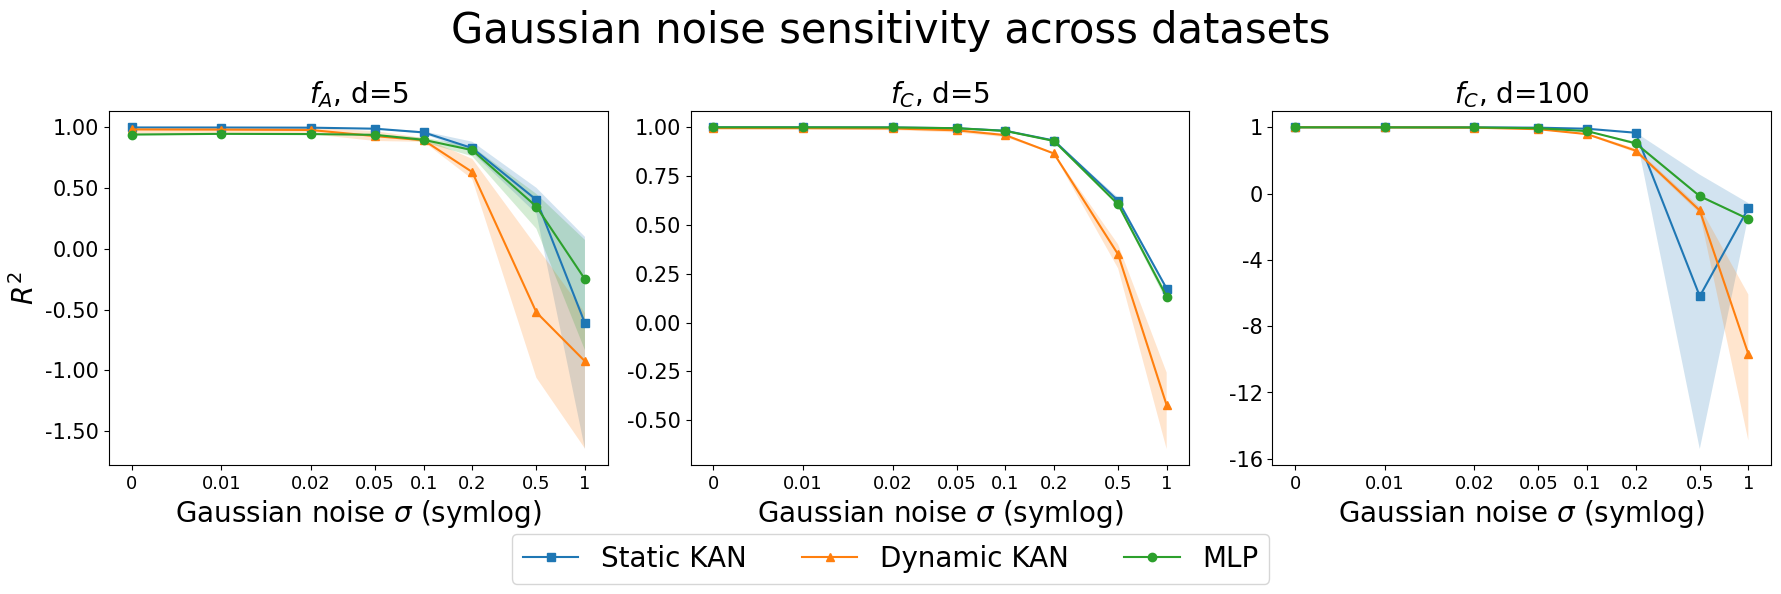

In [70]:
experiments = [
    (A_dim5, 'A', 5),
    (C_dim5, 'C', 5),
    (C_dim100, 'C', 100),
]

plot_gaussian(experiments, seeds, noise_levels)

In [76]:
def plot_extreme(experiments, seeds, x_plot):
    from matplotlib.ticker import MaxNLocator

    plt.rcParams.update({
        'font.size': 13,
        'axes.titlesize': 20,
        'axes.labelsize': 20,
        'xtick.labelsize': 13,
        'ytick.labelsize': 15,
        'legend.fontsize': 20,
        'figure.titlesize': 30
    })

    fig, axes = plt.subplots(1, len(experiments), figsize=(6 * len(experiments), 6))
    if len(experiments) == 1:
        axes = [axes]

    for ax_idx, (ax, (results, data, dim)) in enumerate(zip(axes, experiments)):
        noise_values = sorted(results[seeds[0]].keys())

        static_r2 = np.array([[results[s][n]['static']['r2s'][-1] for n in noise_values] for s in seeds])
        dynamic_r2 = np.array([[results[s][n]['dynamic']['r2s'][-1] for n in noise_values] for s in seeds])
        mlp_r2 = np.array([[results[s][n]['mlp']['r2s'][-1] for n in noise_values] for s in seeds])

        if ax_idx == 2:
            all_r2 = np.concatenate([static_r2.flatten(), dynamic_r2.flatten(), mlp_r2.flatten()])
            ymin_data = float(np.nanmin(all_r2))
            raw_ticks = np.array(sorted(MaxNLocator(nbins=5).tick_values(ymin_data, 1.0)))
            tick_step = float(raw_ticks[1] - raw_ticks[0]) if len(raw_ticks) >= 2 else 0.2

            if tick_step > 1.0:
                def transform(y, _s=tick_step):
                    arr = np.asarray(y, dtype=float)
                    return np.where(arr > 0, arr * _s, arr)
                below = raw_ticks[raw_ticks <= 0.0]
                ytick_pos = list(below) + [tick_step]
                ytick_labels = [str(int(v)) if v == int(v) else f"{v:.2f}" for v in below] + ["1"]
                ymin_t = ymin_data if ymin_data <= 0 else ymin_data * tick_step
                span = tick_step - ymin_t
                ylim = (ymin_t - span * 0.05, tick_step + span * 0.05)
            else:
                transform = lambda y: np.asarray(y, dtype=float)
                ytick_pos = sorted(set(float(t) for t in raw_ticks) | {1.0})
                ytick_labels = None
                span = 1.0 - ymin_data
                ylim = (ymin_data - span * 0.05, 1.0 + tick_step * 0.3)
        else:
            transform = lambda y: np.asarray(y, dtype=float)
            ytick_pos = None
            ytick_labels = None
            ylim = None

        ax.plot(x_plot, transform(static_r2.mean(axis=0)), marker='s', label='Static KAN')
        ax.fill_between(x_plot, transform(static_r2.min(axis=0)), transform(static_r2.max(axis=0)), alpha=0.2)

        ax.plot(x_plot, transform(dynamic_r2.mean(axis=0)), marker='^', label='Dynamic KAN')
        ax.fill_between(x_plot, transform(dynamic_r2.min(axis=0)), transform(dynamic_r2.max(axis=0)), alpha=0.2)

        ax.plot(x_plot, transform(mlp_r2.mean(axis=0)), marker='o', label='MLP')
        ax.fill_between(x_plot, transform(mlp_r2.min(axis=0)), transform(mlp_r2.max(axis=0)), alpha=0.2)

        ax.set_xlabel('$\\%$ of outlier noise')
        if ax_idx == 0:
            ax.set_ylabel('$R^2$')
        ax.set_title(f'Data {data}, dim {dim}')

        ax.set_xticks(x_plot)
        ax.set_xticklabels([f"{val:g}" for val in x_plot])

        if ytick_pos is not None:
            ax.set_yticks(ytick_pos)
        if ytick_labels is not None:
            ax.set_yticklabels(ytick_labels)
        else:
            ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.2f}"))
        if ylim is not None:
            ax.set_ylim(ylim)

    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.05))
    fig.suptitle('Outlier noise sensitivity across datasets')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
    fig.savefig('extreme_noise_sensitivity_all_subfigures.png', bbox_inches='tight', dpi=300)

In [ ]:
seeds = [0, 1, 42]

In [106]:
def load_kan_results_outlier(data_name,  dim):

    compiled_results = {}
    
    search_pattern = os.path.join('6-results-noise-outlier', 'seed-*', f'{data_name}_dim{dim}_outlier_*.pt')
    matching_files = glob.glob(search_pattern)
    
    if not matching_files:
        print('No files found for equation')
        return compiled_results

    for file_path in matching_files:
        path_parts = file_path.split(os.sep)
        seed_str = [part for part in path_parts if part.startswith('seed-')][0]
        seed = int(seed_str.split('-')[1])
        filename = os.path.basename(file_path)
        sigma_str = filename.split('_outlier_')[1].replace('pct.pt', '')
        sigma = float(sigma_str)
        result_data = torch.load(file_path, map_location='cpu', weights_only=False)
        
        if seed not in compiled_results:
            compiled_results[seed] = {}
            
        compiled_results[seed][sigma] = result_data

    print(f"Successfully loaded {len(matching_files)} result file(s).")
    return compiled_results

In [110]:
C_dim100 = load_kan_results_outlier('C', 100)
C_dim5 = load_kan_results_outlier('C', 5)
A_dim5 = load_kan_results_outlier('A', 5)

Successfully loaded 15 result file(s).
Successfully loaded 15 result file(s).
Successfully loaded 15 result file(s).


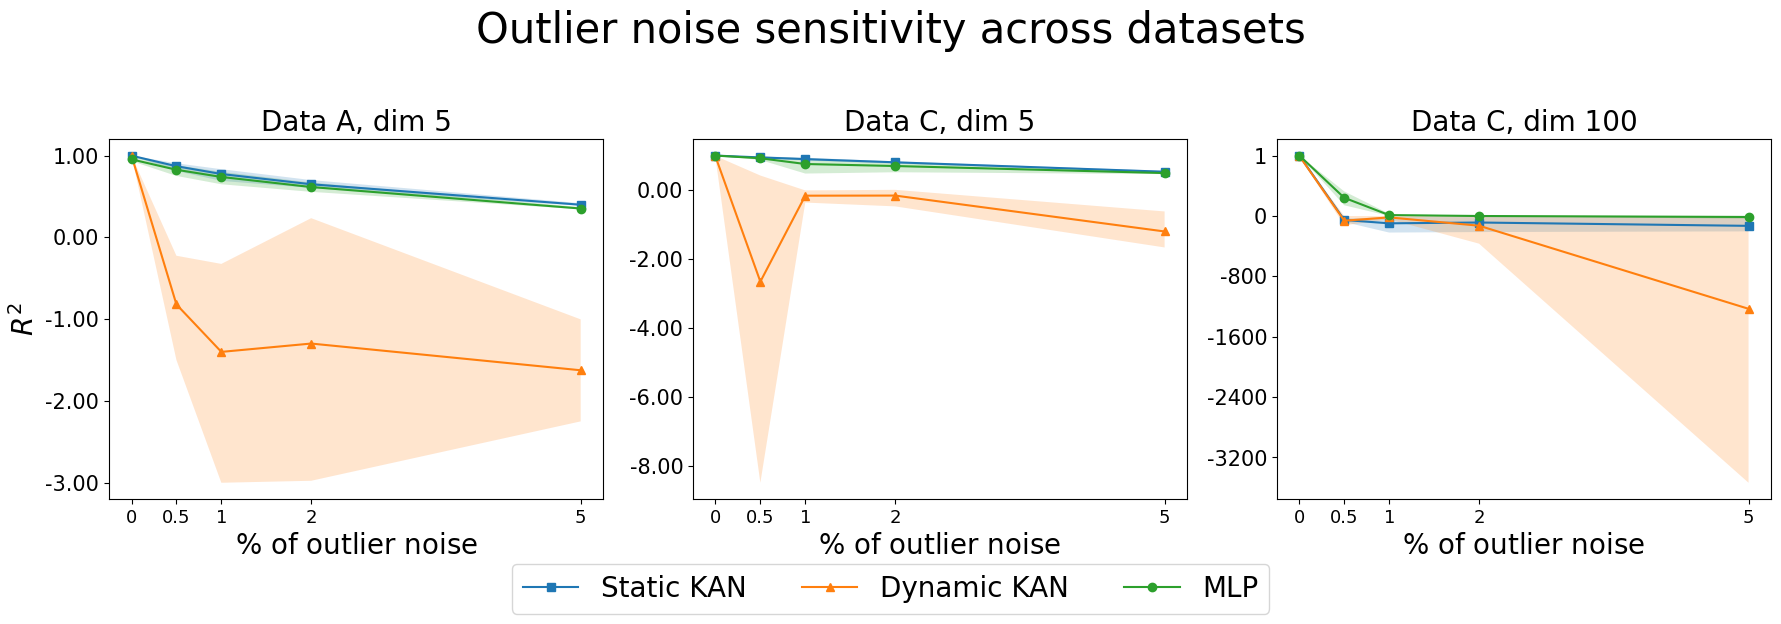

In [111]:
experiments = [
    (A_dim5, 'A', 5),
    (C_dim5, 'C', 5),
    (C_dim100, 'C', 100)
]

plot_extreme(experiments, seeds, pct)